## 대구교통공사 권종별 월별 수송현황 머신러닝 분석

**목표**: 전년도 동일 월 대비 총 이용객 수가 증가할지, 감소할지 예측 (이진 분류)  
**모델**: 의사결정나무 (DecisionTreeClassifier)  
전년동월 이용객 수(lag 12) 추가 — 계절 영향 제거, 연간 추세 비교
2005년 이후 데이터만 사용 — 개통 초기(1997~2004) 노이즈 제거
**분할**: 시간 순서 유지 — 앞 80%를 학습, 뒤 20%를 테스트

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 한글 폰트 설정 (Windows)
import platform
from matplotlib import rc
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')

# 출력 형식 설정
np.set_printoptions(suppress=True, precision=4)
pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.rcParams['font.size'] = 14

random_seed = 123

In [2]:
# 데이터 로드
df = pd.read_csv('input/대구교통공사_권종별월별수송현황_20260228.csv', encoding='euc-kr')

df.columns = ['년', '월',
              '선불카드_일반', '선불카드_청소년', '선불카드_어린이', '선불카드_특수',
              '후불카드_일반', '후불카드_청소년', '후불카드_어린이',
              '아이조아선불_일반', '아이조아선불_청소년', '아이조아선불_어린이', '아이조아후불_일반',
              '무임카드_경로자', '무임카드_장애인', '무임카드_유공자',
              '일반권', '할인권',
              '우대권_경로자', '우대권_장애인', '우대권_유공자',
              '정액권', '정기출입권', '단체권', '기타']

# 총 이용객 수 (권종 23개 합산)
df['총이용객'] = df.iloc[:, 2:25].sum(axis=1)

# [개선 4] 2005년 이후 데이터만 사용 — 개통 초기 노이즈 제거
df = df[df['년'] >= 2005].reset_index(drop=True)

print(f'데이터 크기: {df.shape}')
print(f'기간: {df["년"].iloc[0]}년 {df["월"].iloc[0]}월 ~ {df["년"].iloc[-1]}년 {df["월"].iloc[-1]}월')
print()
print('결측치:')
print(df.isnull().sum())
print()
df.head()

데이터 크기: (254, 26)
기간: 2005년 1월 ~ 2026년 2월

결측치:
년             0
월             0
선불카드_일반       0
선불카드_청소년      0
선불카드_어린이      0
선불카드_특수       0
후불카드_일반       0
후불카드_청소년      0
후불카드_어린이      0
아이조아선불_일반     0
아이조아선불_청소년    0
아이조아선불_어린이    0
아이조아후불_일반     0
무임카드_경로자      0
무임카드_장애인      0
무임카드_유공자      0
일반권           0
할인권           0
우대권_경로자       0
우대권_장애인       0
우대권_유공자       0
정액권           0
정기출입권         0
단체권           0
기타            0
총이용객          0
dtype: int64



,년,월,선불카드_일반,선불카드_청소년,선불카드_어린이,선불카드_특수,후불카드_일반,후불카드_청소년,후불카드_어린이,아이조아선불_일반,아이조아선불_청소년,아이조아선불_어린이,아이조아후불_일반,무임카드_경로자,무임카드_장애인,무임카드_유공자,일반권,할인권,우대권_경로자,우대권_장애인,우대권_유공자,정액권,정기출입권,단체권,기타,총이용객
0,2005,1,1397976,185171,0,0,125551,0,0,0,0,0,0,0,0,0,1564508,97115,657650,110655,16480,0,0,499,16433,4172038
1,2005,2,1231063,169756,0,0,112472,0,0,0,0,0,0,0,0,0,1403795,90517,566999,95402,14209,0,0,470,50813,3735496
2,2005,3,1668078,302486,0,0,138452,0,0,0,0,0,0,0,0,0,1423168,54322,732171,123193,18348,0,0,228,64198,4524644
3,2005,4,1598864,280716,0,0,137686,0,0,0,0,0,0,0,0,0,1367589,55657,742388,124913,18604,0,0,3076,60714,4390207
4,2005,5,1622963,290737,0,0,146540,0,0,0,0,0,0,0,0,0,1423503,67169,783073,131758,19624,0,0,1114,56987,4543468


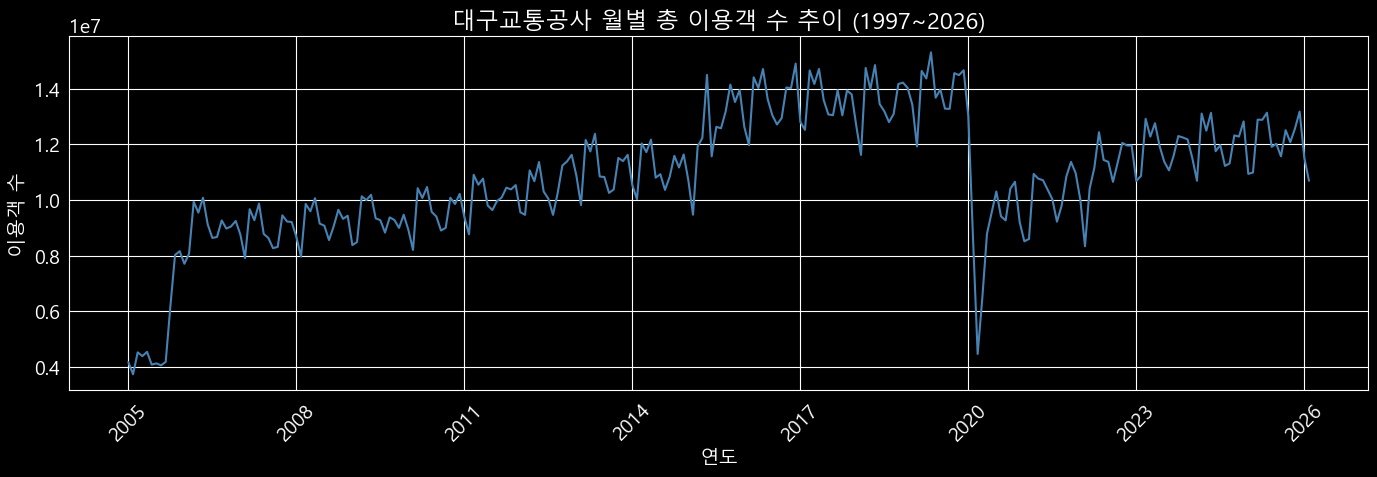

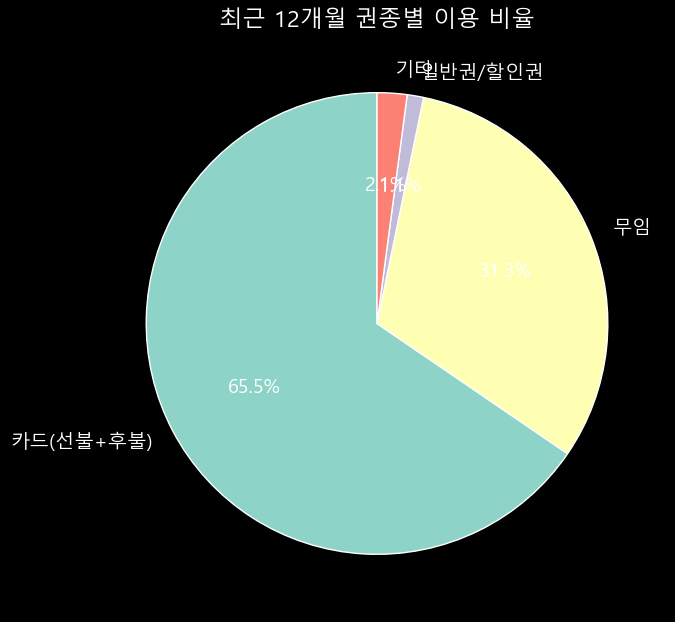

In [3]:
# 월별 총 이용객 추이
plt.figure(figsize=(14, 5))
plt.plot(range(len(df)), df['총이용객'], linewidth=1.5, color='steelblue')
year_idx = df[df['월'] == 1].index
year_labels = df[df['월'] == 1]['년'].values
plt.xticks(year_idx[::3], year_labels[::3], rotation=45)
plt.title('대구교통공사 월별 총 이용객 수 추이 (1997~2026)')
plt.xlabel('연도')
plt.ylabel('이용객 수')
plt.tight_layout()
plt.show()

# 최근 12개월 권종별 이용 비율 (파이차트)
recent = df.tail(12)
카드이용  = recent[['선불카드_일반','선불카드_청소년','선불카드_어린이',
                     '후불카드_일반','후불카드_청소년','후불카드_어린이']].sum().sum()
무임이용  = recent[['무임카드_경로자','무임카드_장애인','무임카드_유공자',
                     '우대권_경로자','우대권_장애인','우대권_유공자']].sum().sum()
일반권이용 = recent[['일반권','할인권']].sum().sum()
기타이용  = recent['기타'].sum()

sizes  = [카드이용, 무임이용, 일반권이용, 기타이용]
labels = ['카드(선불+후불)', '무임', '일반권/할인권', '기타']
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('최근 12개월 권종별 이용 비율')
plt.tight_layout()
plt.show()

In [4]:
# 무임 이용객 (경로자, 장애인, 유공자 우대)
df['무임이용객'] = (df['무임카드_경로자'] + df['무임카드_장애인'] + df['무임카드_유공자'] +
                    df['우대권_경로자'] + df['우대권_장애인'] + df['우대권_유공자'])

# 유료 이용객
df['유료이용객'] = df['총이용객'] - df['무임이용객']

# [개선 1] 전년동월 lag 피처 — shift(12)로 1년 전 동일 월 값 참조
df['전년동월_총이용객']  = df['총이용객'].shift(12)
df['전년동월_유료이용객'] = df['유료이용객'].shift(12)

# 타겟: 전년도 동일 월 대비 총 이용객 증가(1) / 감소(0)
df['증감'] = (df['총이용객'] > df['총이용객'].shift(12)).astype(int)

# 앞 12행 제거 (shift(12)로 인해 비교 불가)
df = df.iloc[12:].reset_index(drop=True)

print(df[['년', '월', '총이용객', '전년동월_총이용객', '증감']].head(12))
print()
print('증감 분포:')
print(df['증감'].value_counts())
print(f'\n증가 비율: {df["증감"].mean():.2%}')

       년   월      총이용객      전년동월_총이용객  증감
0   2006   1   7709545 4,172,038.0000   1
1   2006   2   8068894 3,735,496.0000   1
2   2006   3   9939146 4,524,644.0000   1
3   2006   4   9550032 4,390,207.0000   1
4   2006   5  10084113 4,543,468.0000   1
5   2006   6   9124760 4,083,971.0000   1
6   2006   7   8638933 4,128,639.0000   1
7   2006   8   8673086 4,059,108.0000   1
8   2006   9   9266955 4,179,497.0000   1
9   2006  10   8976236 6,177,239.0000   1
10  2006  11   9050275 8,026,398.0000   1
11  2006  12   9249522 8,162,904.0000   1

증감 분포:
증감
1    180
0     62
Name: count, dtype: int64

증가 비율: 74.38%


In [5]:
# 피처 / 타겟 설정 — 전년동월 lag 피처 포함
feature_cols = ['년', '월', '유료이용객', '무임이용객', '전년동월_총이용객', '전년동월_유료이용객']
X = df[feature_cols]
y = df['증감']

# 시간 순서 유지 - 마지막 20%를 테스트 데이터로
split_idx = int(len(df) * 0.8)
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f'전체 데이터: {len(df)}행')
print(f'학습 데이터: {len(X_train)}행  '
      f'({df["년"].iloc[0]}년 {df["월"].iloc[0]}월 ~ '
      f'{df["년"].iloc[split_idx-1]}년 {df["월"].iloc[split_idx-1]}월)')
print(f'테스트 데이터: {len(X_test)}행  '
      f'({df["년"].iloc[split_idx]}년 {df["월"].iloc[split_idx]}월 ~ '
      f'{df["년"].iloc[-1]}년 {df["월"].iloc[-1]}월)')
print()
print('학습 타겟 분포:')
print(y_train.value_counts())
print()
print('테스트 타겟 분포:')
print(y_test.value_counts())

전체 데이터: 242행
학습 데이터: 193행  (2006년 1월 ~ 2022년 1월)
테스트 데이터: 49행  (2022년 2월 ~ 2026년 2월)

학습 타겟 분포:
증감
1    140
0     53
Name: count, dtype: int64

테스트 타겟 분포:
증감
1    40
0     9
Name: count, dtype: int64


In [6]:
from sklearn.tree import DecisionTreeClassifier, export_text

# 의사결정나무 모델 학습
dt_model = DecisionTreeClassifier(max_depth=4, random_state=random_seed)
dt_model.fit(X_train, y_train)

# 예측
y_pred_dt = dt_model.predict(X_test)

# 평가
print('=== 의사결정나무 분류 결과 ===')
print(f'정확도(Accuracy): {accuracy_score(y_test, y_pred_dt):.4f}')
print()
print('혼동행렬:')
print(confusion_matrix(y_test, y_pred_dt))
print()
print('분류 리포트:')
print(classification_report(y_test, y_pred_dt, target_names=['감소(0)', '증가(1)']))
print()
print('=== 의사결정나무 규칙 ===')
print(export_text(dt_model, feature_names=feature_cols))

=== 의사결정나무 분류 결과 ===
정확도(Accuracy): 0.8571

혼동행렬:
[[ 2  7]
 [ 0 40]]

분류 리포트:
              precision    recall  f1-score   support

       감소(0)       1.00      0.22      0.36         9
       증가(1)       0.85      1.00      0.92        40

    accuracy                           0.86        49
   macro avg       0.93      0.61      0.64        49
weighted avg       0.88      0.86      0.82        49


=== 의사결정나무 규칙 ===
|--- 유료이용객 <= 6645148.50
|   |--- 전년동월_유료이용객 <= 6350904.50
|   |   |--- 년 <= 2015.00
|   |   |   |--- class: 1
|   |   |--- 년 >  2015.00
|   |   |   |--- class: 0
|   |--- 전년동월_유료이용객 >  6350904.50
|   |   |--- class: 0
|--- 유료이용객 >  6645148.50
|   |--- 전년동월_유료이용객 <= 9442440.00
|   |   |--- 전년동월_유료이용객 <= 7175681.50
|   |   |   |--- class: 1
|   |   |--- 전년동월_유료이용객 >  7175681.50
|   |   |   |--- 유료이용객 <= 7316499.50
|   |   |   |   |--- class: 0
|   |   |   |--- 유료이용객 >  7316499.50
|   |   |   |   |--- class: 1
|   |--- 전년동월_유료이용객 >  9442440.00
|   |   |--- 유료이용객 <= 995151

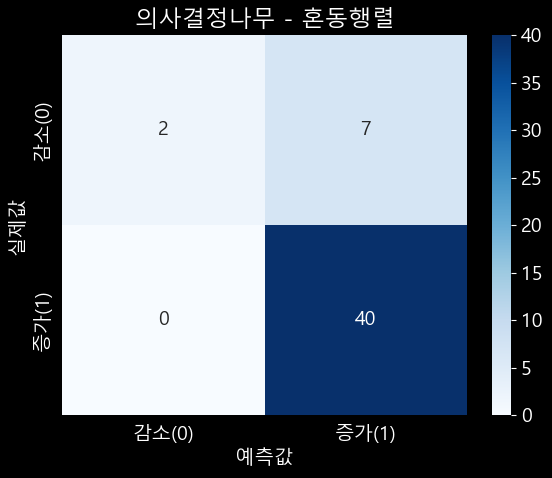

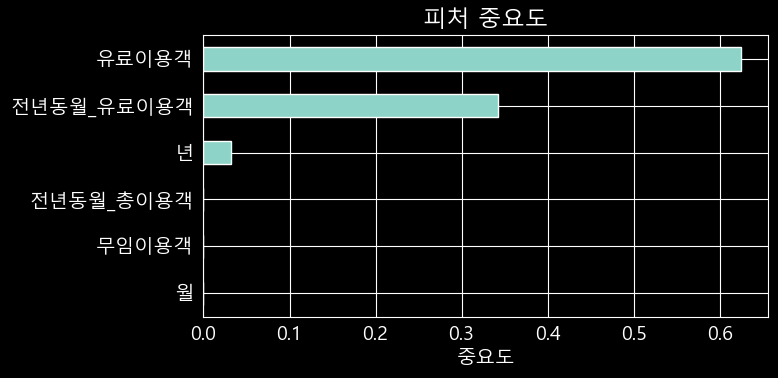

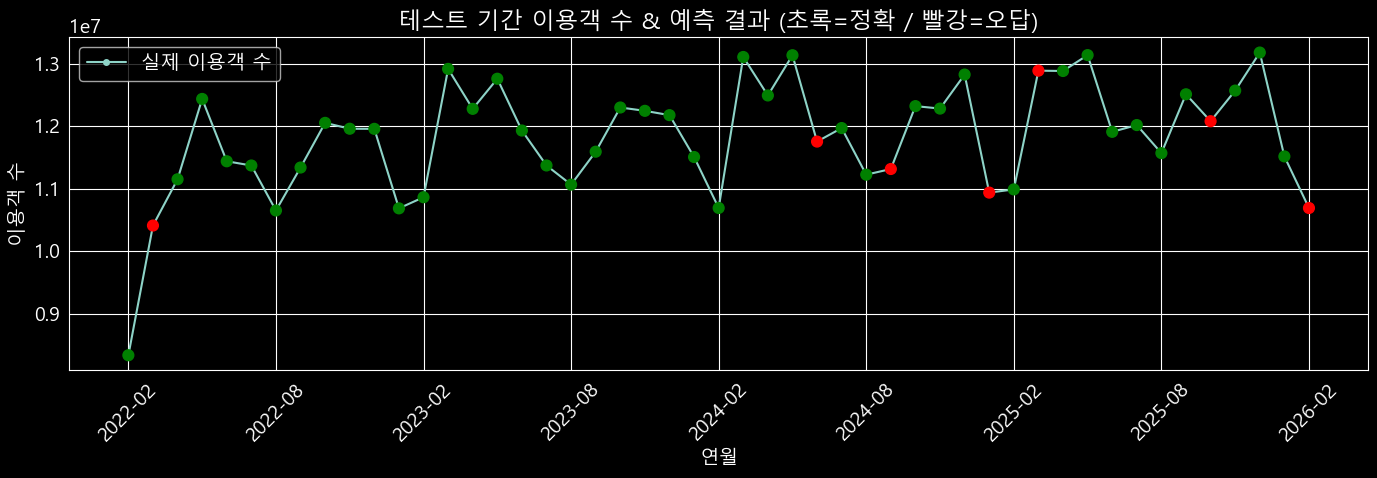

In [7]:
# 혼동행렬 시각화
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['감소(0)', '증가(1)'],
            yticklabels=['감소(0)', '증가(1)'])
plt.title('의사결정나무 - 혼동행렬')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

# 피처 중요도
importance = pd.Series(dt_model.feature_importances_, index=feature_cols)
importance.sort_values().plot(kind='barh', figsize=(8, 4))
plt.title('피처 중요도')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

# 예측 vs 실제 비교
test_df = df.iloc[split_idx:].copy().reset_index(drop=True)
test_df['예측'] = y_pred_dt

plt.figure(figsize=(14, 5))
plt.plot(range(len(test_df)), test_df['총이용객'], label='실제 이용객 수', marker='o', markersize=4)
colors = ['green' if p == a else 'red' for p, a in zip(test_df['예측'], test_df['증감'])]
plt.scatter(range(len(test_df)), test_df['총이용객'], c=colors, zorder=5, s=60)
tick_pos = list(range(0, len(test_df), 6))
tick_lab = [f"{test_df['년'].iloc[i]}-{test_df['월'].iloc[i]:02d}" for i in tick_pos]
plt.xticks(tick_pos, tick_lab, rotation=45)
plt.title('테스트 기간 이용객 수 & 예측 결과 (초록=정확 / 빨강=오답)')
plt.xlabel('연월')
plt.ylabel('이용객 수')
plt.legend()
plt.tight_layout()
plt.show()